### Statistical Learning for Data Science 2 (229352)
#### Instructor: Donlapark Ponnoprat

#### [Course website](https://donlapark.pages.dev/229352/)

## Lab #9

[Recipe for Training Neural Networks](https://karpathy.github.io/2019/04/25/recipe/)

In [1]:
%%capture
!git clone https://github.com/donlapark/ds352-labs.git

In [2]:
import numpy as np

import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader, random_split
from torch.utils.tensorboard import SummaryWriter
import matplotlib.pyplot as plt

## Training a neural network in PyTorch

### Chihuahua or Muffin?

<center><img src="https://donlapark.pages.dev/229352/lab09-preview.jpg" width="500"/></center>

### 1. Data preparation

#### Load images, resize them to 128x128, and normalize the pixels to be in 0 - 1 range

In [3]:
transform = transforms.Compose([transforms.Resize((128, 128)),
                                transforms.ToTensor()])  # transform pixels to be in 0 - 1 range

dataset = datasets.ImageFolder(root="ds352-labs/lab09-data/train",
                                         transform=transform)

#### Split the dataset into training (80%), validation (20%)

In [4]:
train_size = int(0.8 * len(dataset))
val_size = len(dataset) - train_size
train_dataset, val_dataset = random_split(dataset, [train_size, val_size])

#### Load the datasets into DataLoader

In [5]:
train_loader = DataLoader(dataset=train_dataset,
                          batch_size=10,
                          shuffle=True)
val_loader = DataLoader(dataset=val_dataset,
                        batch_size=len(val_dataset),
                        shuffle=False)

#### Do the same for the test images

In [6]:
test_dataset = datasets.ImageFolder(root="ds352-labs/lab09-data/test",
                                    transform=transform)
test_loader = DataLoader(dataset=test_dataset,
                         batch_size=len(test_dataset),
                         shuffle=False)

#### Looking at the first minibatch

In [7]:
train_batches = iter(train_loader)
X, y = next(train_batches)

print(X.shape)  # (batch_size, channel, height, weight)
print(y.shape)

torch.Size([10, 3, 128, 128])
torch.Size([10])


#### Visualize the first four images in the batch

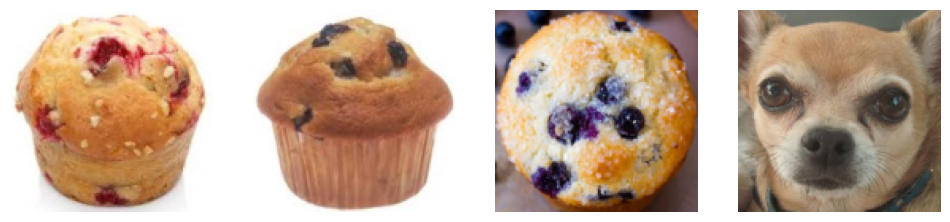

tensor([1, 1, 1, 0])


In [8]:
X = X[:4]  # Select the first 4 images
X = X.numpy().transpose(0, 2, 3, 1)  # Convert from (B, C, H, W) to (B, H, W, C)

# Plot images
fig, axes = plt.subplots(1, 4, figsize=(12, 4))
for i in range(4):
    axes[i].imshow(X[i])
    axes[i].axis('off')
plt.show()

print(y[:4])

### 2. Build a simple logistic regression

<center><img src="https://donlapark.pages.dev/229352/logistic.png" width="300"/></center>

The most important component of the model class is the `__init__` method and the `forward` method.  

[Linear layer in Pytorch](https://docs.pytorch.org/docs/stable/generated/torch.nn.Linear.html)

[Activation functions in PyTorch](https://pytorch.org/docs/stable/nn.html#non-linear-activations-weighted-sum-nonlinearity). The most important ones are [ReLU](https://pytorch.org/docs/stable/generated/torch.nn.ReLU.html), [Sigmoid](https://pytorch.org/docs/stable/generated/torch.nn.Sigmoid.html), [Softmax](https://pytorch.org/docs/stable/generated/torch.nn.Softmax.html), [Tanh](https://pytorch.org/docs/stable/generated/torch.nn.Tanh.html).

In [10]:
class SimpleLogisticRegression(nn.Module):
    def __init__(self):
        super(SimpleLogisticRegression, self).__init__()
        # Input images are 128x128 with 3 channels (RGB)
        self.flatten = nn.Flatten()
        # The output layer should have 2 units for binary classification with CrossEntropyLoss
        self.linear = nn.Linear(128 * 128 * 3, 2)

    def forward(self, x):
        x = self.flatten(x)
        x = self.linear(x)
        return x

### 3. Initialize training components

#### Initialize the model and loss function

[Loss functions in PyTorch](https://pytorch.org/docs/stable/nn.html#loss-functions). Most important ones are [MSE](https://pytorch.org/docs/stable/generated/torch.nn.MSELoss.html), [Binary cross, entropy](https://pytorch.org/docs/stable/generated/torch.nn.BCELoss.html), [Categorical cross entropy](https://pytorch.org/docs/stable/generated/torch.nn.CrossEntropyLoss.html).

In [11]:
model = SimpleLogisticRegression()
criterion = nn.CrossEntropyLoss()

#### Manually setting initial weights to zero for demonstration

In [12]:
with torch.no_grad():
  for layer in model.modules():
      if isinstance(layer, nn.Linear):
          layer.weight.zero_()
          layer.bias.zero_()

#### Create two lists to collect training and validation losses

In [13]:
# List to store the loss values for plotting
train_losses = []
val_losses = []

#### Specify the learning rate

In [14]:
learning_rate = 1e-3
optimizer = optim.AdamW(model.parameters(), lr=learning_rate)

### 4. Training the model with gradient descent

#### Convert the dataloader into minibatches

In [15]:
X, y = next(iter(train_loader))

#### Make a prediction on the minibatch (Forward pass)

In [16]:
y_hat = model(X)

#### Calculate the loss function

Recall that `criterion()` is our binary cross-entropy loss (`BCELoss`).

In [17]:
loss = criterion(y_hat, y)

#### Calculate the gradient (Backward pass)

In [18]:
loss.backward() # Backward pass: compute the gradient of the loss w.r.t. model parameters

#### Perform a gradient descent step

Careful! We must not include this step in the gradient calculation, hence the use of `with torch.no_grad()`.

In [19]:
optimizer.step() # Update the weights using the gradient descent rule
optimizer.zero_grad() # Zero the gradients after updating

#### Do the same for the validation set

Careful! Anything in the validation step must not be included in the gradient calculation, hence the use of `with torch.no_grad()`.

In [23]:
with torch.no_grad():
  for X, y in val_loader:
    y_hat = model(X)
    # y_hat should be (batch_size, 2) for CrossEntropyLoss with 2 classes
    # y should be of type LongTensor (torch.int64) for CrossEntropyLoss
    val_loss = criterion(y_hat, y)
    val_losses.append(val_loss.item())

In [21]:
print(train_losses)
print(val_losses)

[]
[95.06784057617188]


#### Combine everything together.

Repeat the previous steps for 20 **epochs** and plot the training and validation losses.

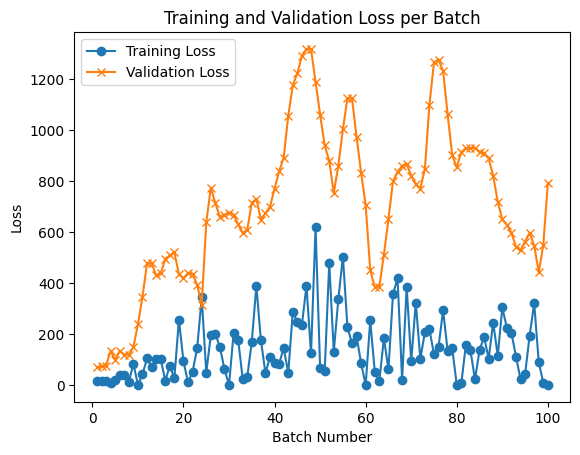

In [22]:
model = SimpleLogisticRegression()
criterion = nn.CrossEntropyLoss()
optimizer = optim.SGD(model.parameters(), lr=1e-3, momentum=0.9)

with torch.no_grad():
  for layer in model.modules():
      if isinstance(layer, nn.Linear):
          layer.weight.zero_()
          layer.bias.zero_()

train_losses = []
val_losses = []

learning_rate = 1e-4

for epoch in range(10):
  for X, y in train_loader:
    y_hat = model(X)
    y_hat = y_hat[:, 0]
    y = y.to(torch.float32)

    loss = criterion(y_hat, y)
    train_losses.append(loss.item())

    loss.backward()
    optimizer.step()

    # Zero the gradients after updating
    model.zero_grad()

    with torch.no_grad():
      for X, y in val_loader:
        y_hat = model(X)
        y_hat = y_hat[:, 0]
        y = y.to(torch.float32)
        val_loss = criterion(y_hat, y)
        val_losses.append(val_loss)

# Plot the training and validation loss
plt.plot(range(1, len(train_losses)+1), train_losses, marker='o', label='Training Loss')
plt.plot(range(1, len(val_losses)+1), val_losses, marker='x', label='Validation Loss')
plt.title('Training and Validation Loss per Batch')
plt.xlabel('Batch Number')
plt.ylabel('Loss')
plt.legend()
plt.show()

# Exercise

In this exercise, we will add more layers to our classification model.

<img src="https://donlapark.pages.dev/229352/lab09-architecture.png" width="450"/>

1. Create a neural network with 3 hidden layers as shown in the picture.

2. Train the model with learning rate = 1e-2, 1e-3, 1e-4, 1e-5, and answer the following questions.
    2.1 What value of learning rate do you **think** is the best? Please explain your reason.
    2.2 What happens to the training losses if your learning rate is too large?
    2.3 What happens to the training losses if your learning rate is too small?

3. After finish training your model. Make the predictions on the test set and compute the accuracy. You may use the provided code below.

4. Use `plt.imshow()` to display at least four images that are incorrectly classified by this model.

In [24]:
with torch.no_grad():
  test_batches = iter(test_loader)
  X, y = next(test_batches)
  y_hat = model(X)
  y_hat = y_hat[:, 0]
  y_hat = (y_hat > 0.5).float()

In [25]:
class NeuralNetwork(nn.Module):
    def __init__(self):
        super(NeuralNetwork, self).__init__()
        self.flatten = nn.Flatten()
        self.linear_relu_stack = nn.Sequential(
            nn.Linear(128 * 128 * 3, 1024),
            nn.ReLU(),
            nn.Linear(1024, 512),
            nn.ReLU(),
            nn.Linear(512, 128),
            nn.ReLU(),
            nn.Linear(128, 2)
        )

    def forward(self, x):
        x = self.flatten(x)
        logits = self.linear_relu_stack(x)
        return logits


Training with learning rate: 0.01


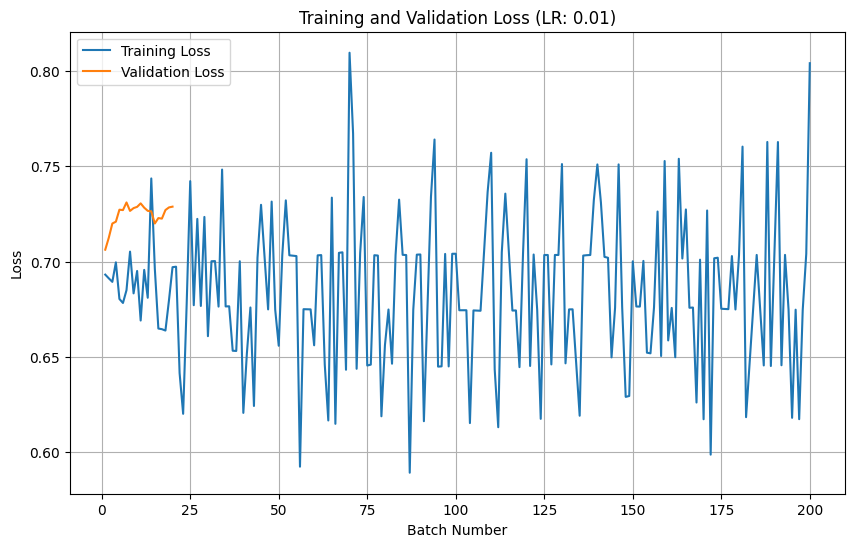


Training with learning rate: 0.001


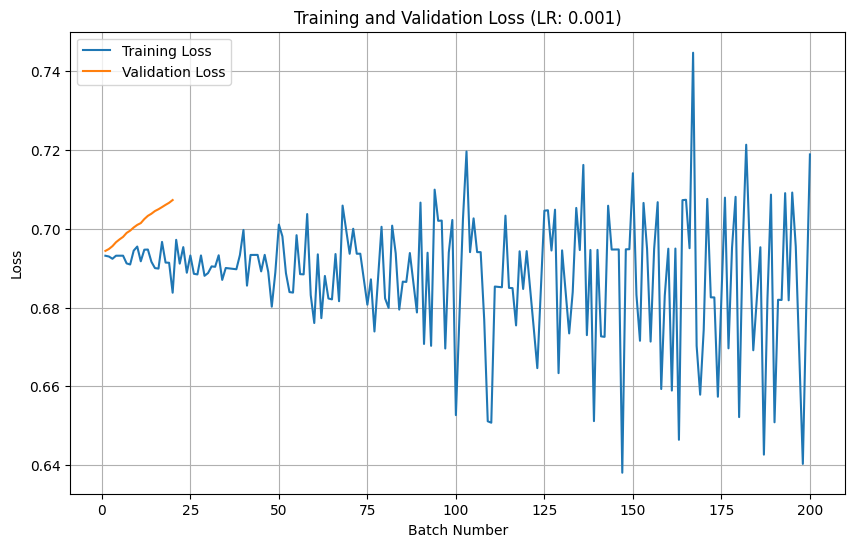


Training with learning rate: 0.0001


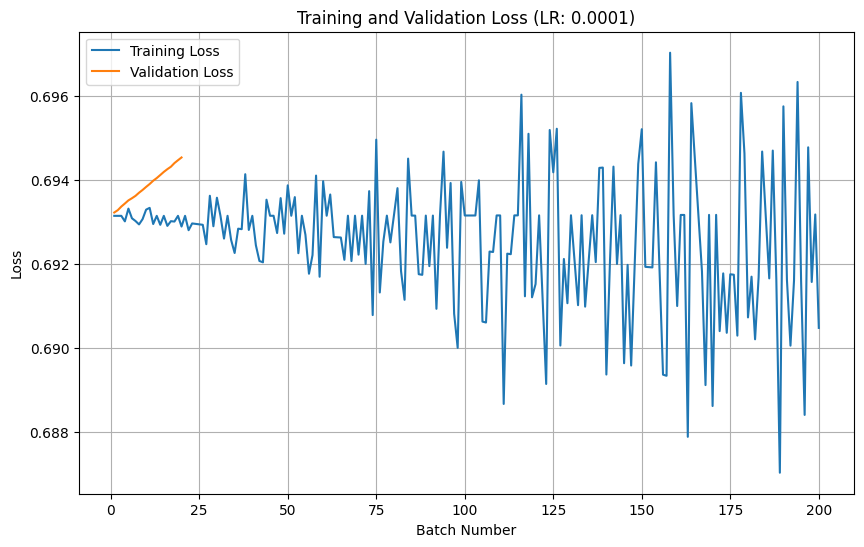


Training with learning rate: 1e-05


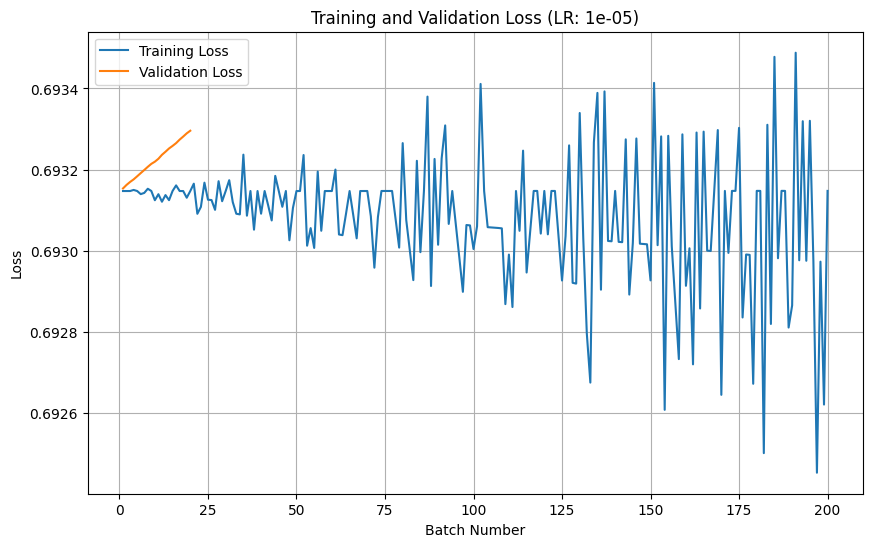

In [26]:
learning_rates = [1e-2, 1e-3, 1e-4, 1e-5]
num_epochs = 20

for lr in learning_rates:
    print(f"\nTraining with learning rate: {lr}")

    model = NeuralNetwork()

    criterion = nn.CrossEntropyLoss()

    optimizer = optim.AdamW(model.parameters(), lr=lr)

    with torch.no_grad():
        for layer in model.modules():
            if isinstance(layer, nn.Linear):
                layer.weight.zero_()
                layer.bias.zero_()

    train_losses_lr = []
    val_losses_lr = []

    for epoch in range(num_epochs):
        model.train()
        current_epoch_train_losses = []
        for X_train, y_train in train_loader:
            y_hat_train = model(X_train)

            loss = criterion(y_hat_train, y_train)
            current_epoch_train_losses.append(loss.item())

            loss.backward()

            optimizer.step()

            optimizer.zero_grad()

        train_losses_lr.extend(current_epoch_train_losses)

        model.eval()
        with torch.no_grad():
            current_epoch_val_losses = []
            for X_val, y_val in val_loader:
                y_hat_val = model(X_val)

                val_loss = criterion(y_hat_val, y_val)
                current_epoch_val_losses.append(val_loss.item())

            val_losses_lr.extend(current_epoch_val_losses)

    plt.figure(figsize=(10, 6))
    plt.plot(range(1, len(train_losses_lr) + 1), train_losses_lr, label='Training Loss')
    plt.plot(range(1, len(val_losses_lr) + 1), val_losses_lr, label='Validation Loss')

    plt.title(f'Training and Validation Loss (LR: {lr})')
    plt.xlabel('Batch Number')
    plt.ylabel('Loss')
    plt.legend()
    plt.grid(True)
    plt.show()


Retraining with optimal learning rate: 1e-3


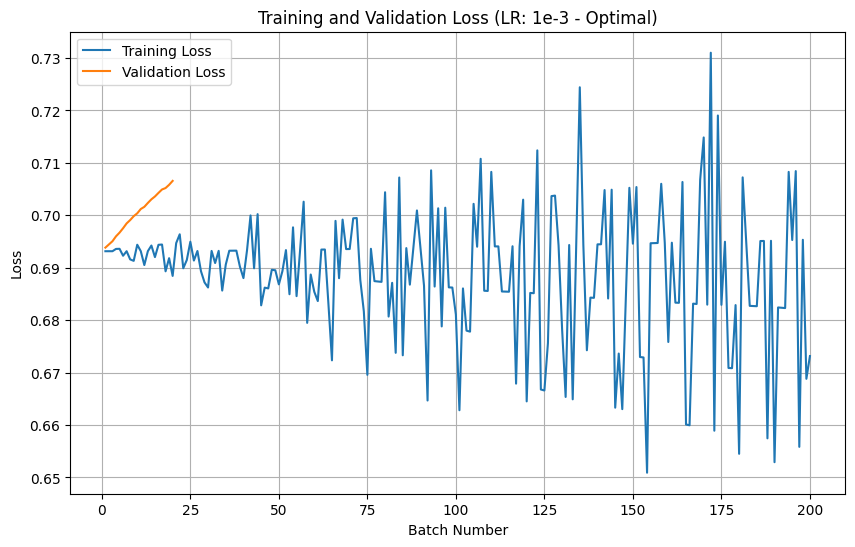

In [27]:
print(f"\nRetraining with optimal learning rate: 1e-3")

model = NeuralNetwork()
criterion = nn.CrossEntropyLoss()
optimizer = optim.AdamW(model.parameters(), lr=1e-3)
num_epochs = 20

with torch.no_grad():
    for layer in model.modules():
        if isinstance(layer, nn.Linear):
            layer.weight.zero_()
            layer.bias.zero_()

final_train_losses = []
final_val_losses = []

for epoch in range(num_epochs):
    model.train()
    current_epoch_train_losses = []
    for X_train, y_train in train_loader:
        y_hat_train = model(X_train)
        loss = criterion(y_hat_train, y_train)
        current_epoch_train_losses.append(loss.item())

        loss.backward()
        optimizer.step()
        optimizer.zero_grad()

    final_train_losses.extend(current_epoch_train_losses)

    model.eval()
    with torch.no_grad():
        current_epoch_val_losses = []
        for X_val, y_val in val_loader:
            y_hat_val = model(X_val)
            val_loss = criterion(y_hat_val, y_val)
            current_epoch_val_losses.append(val_loss.item())

        final_val_losses.extend(current_epoch_val_losses)

plt.figure(figsize=(10, 6))
plt.plot(range(1, len(final_train_losses) + 1), final_train_losses, label='Training Loss')
plt.plot(range(1, len(final_val_losses) + 1), final_val_losses, label='Validation Loss')
plt.title(f'Training and Validation Loss (LR: 1e-3 - Optimal)')
plt.xlabel('Batch Number')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.show()

In [28]:
model.eval()
correct_predictions = 0
total_samples = 0

with torch.no_grad():
    for X_test, y_test in test_loader:
        outputs = model(X_test)
        _, predicted = torch.max(outputs.data, 1)
        total_samples += y_test.size(0)
        correct_predictions += (predicted == y_test).sum().item()

accuracy = 100 * correct_predictions / total_samples
print(f'Accuracy on the test set: {accuracy:.2f}%')

Accuracy on the test set: 56.67%


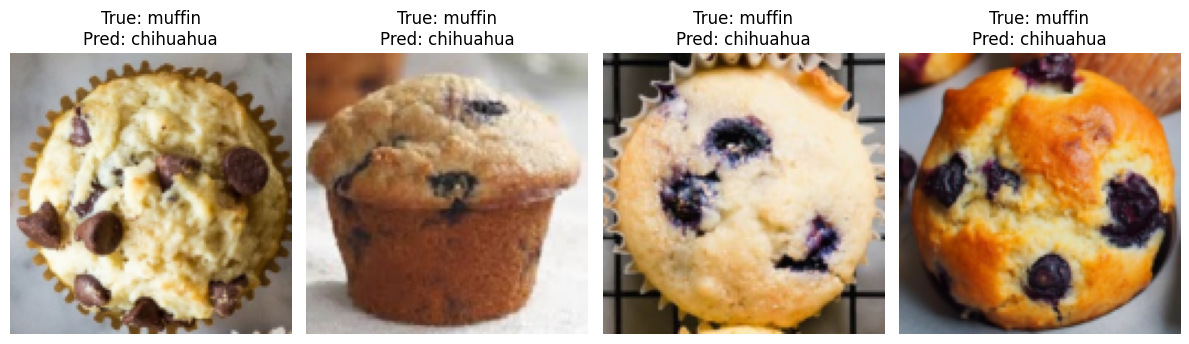

In [29]:
model.eval()
misclassified_images = []
misclassified_labels = []
predicted_labels = []

with torch.no_grad():
    for X_test, y_test in test_loader:
        outputs = model(X_test)
        _, predictions = torch.max(outputs.data, 1)

        incorrect_indices = (predictions != y_test).nonzero(as_tuple=True)[0]

        for idx in incorrect_indices:
            if len(misclassified_images) < 4:
                misclassified_images.append(X_test[idx].cpu().numpy())
                misclassified_labels.append(y_test[idx].item())
                predicted_labels.append(predictions[idx].item())
            else:
                break

    misclassified_images_np = [img.transpose(1, 2, 0) for img in misclassified_images]

    class_names = dataset.classes

    fig, axes = plt.subplots(1, len(misclassified_images_np), figsize=(12, 4))
    if len(misclassified_images_np) == 1:
        axes = [axes]

    for i, ax in enumerate(axes):
        ax.imshow(misclassified_images_np[i])
        ax.set_title(f"True: {class_names[misclassified_labels[i]]}\nPred: {class_names[predicted_labels[i]]}")
        ax.axis('off')
    plt.tight_layout()
    plt.show()


*   **2.1 What value of learning rate do you think is the best? Please explain your reason.**

ค่า learning rate ที่เหมาะสมที่สุดคือ 1e-3 (0.001) เนื่องจากทั้งค่า training loss และ validation loss มีแนวโน้มลดลง สม่ำเสมอและมีนัยสำคัญ
*   **2.2 What happens to the training losses if your learning rate is too large?**

หาก learning rate มีค่ามากเกินไป ค่า training loss จะมีความไม่เสถียรสูง หรือแกว่งขึ้นลงอย่างรุนแรง สาเหตุคือ optimizer ก้าวกระโดดครั้งละมากเกินไป ทำให้เลยจุดต่ำสุดของฟังก์ชัน loss ส่งผลให้โมเดลไม่ลู่เข้าหรือเกิดความยากลำบากในการลู่เข้า
*   **2.3 What happens to the training losses if your learning rate is too small?**

หาก learning rate มีค่าน้อยเกินไป ค่า training loss จะลดลงอย่างช้ามาก เนื่องจาก optimizer ปรับค่าน้ำหนักทีละเล็กน้อยมาก ทำให้การลู่เข้าเกิดขึ้นช้า หรืออาจทำให้โมเดลติดอยู่ที่จุดต่ำสุดเฉพาะที่หรือบริเวณที่ loss แบนราบได้

